In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

misc_against = pd.read_csv(
    r"../data/overwiev__stats_squads_misc_against.csv"
)

misc_against.head()

,Squad,# Pl,90s,Performance_CrdY,Performance_CrdR,Performance_2CrdY,Performance_Fls,Performance_Fld,Performance_Off,Performance_Crs,Performance_Int,Performance_TklW,Performance_PKwon,Performance_PKcon,Performance_OG
0,vs Arsenal,25,38.0,83,2,1,416,390,38,534,261,420,3,2,2
1,vs Aston Villa,28,38.0,104,2,1,510,394,93,683,347,387,2,6,2
2,vs Bournemouth,29,38.0,94,5,3,410,510,42,601,279,396,3,7,1
3,vs Brentford,28,38.0,82,3,2,355,316,58,793,287,362,1,6,1
4,vs Brighton,32,38.0,93,5,4,427,421,88,543,320,408,7,7,2


In [2]:
misc_against = misc_against.rename(columns={
    "Squad": "team",
    "# Pl": "players_faced",
    "Performance_CrdY": "yellow_cards_against",
    "Performance_CrdR": "red_cards_against",
    "Performance_2CrdY": "second_yellow_against",
    "Performance_Fls": "fouls_committed_by_opponent",
    "Performance_Fld": "fouls_drawn_by_team",
    "Performance_Off": "offsides_against",
    "Performance_Crs": "crosses_against",
    "Performance_Int": "interceptions_against",
    "Performance_TklW": "tackles_won_by_opponent"
})

misc_against["team"] = misc_against["team"].str.replace("vs ", "", regex=False)
misc_against["team"] = misc_against["team"].str.strip()

misc_against.head()

,team,players_faced,90s,yellow_cards_against,red_cards_against,second_yellow_against,fouls_committed_by_opponent,fouls_drawn_by_team,offsides_against,crosses_against,interceptions_against,tackles_won_by_opponent,Performance_PKwon,Performance_PKcon,Performance_OG
0,Arsenal,25,38.0,83,2,1,416,390,38,534,261,420,3,2,2
1,Aston Villa,28,38.0,104,2,1,510,394,93,683,347,387,2,6,2
2,Bournemouth,29,38.0,94,5,3,410,510,42,601,279,396,3,7,1
3,Brentford,28,38.0,82,3,2,355,316,58,793,287,362,1,6,1
4,Brighton,32,38.0,93,5,4,427,421,88,543,320,408,7,7,2


In [3]:
misc_against["opponent_aggression_index"] = (
    misc_against["fouls_committed_by_opponent"] +
    misc_against["tackles_won_by_opponent"] +
    misc_against["interceptions_against"]
)

In [4]:
misc_against["opponent_discipline_pressure"] = (
    misc_against["yellow_cards_against"] +
    misc_against["red_cards_against"] * 2
)

In [5]:
pressure_rank = misc_against.sort_values(
    by="opponent_aggression_index",
    ascending=False
)

pressure_rank[[
    "team",
    "opponent_aggression_index"
]]

,team,opponent_aggression_index
17,Tottenham Hotspur,1433
1,Aston Villa,1244
14,Newcastle United,1198
19,Wolves,1172
4,Brighton,1155
16,Southampton,1151
18,West Ham United,1143
13,Manchester Utd,1124
5,Chelsea,1111
0,Arsenal,1097


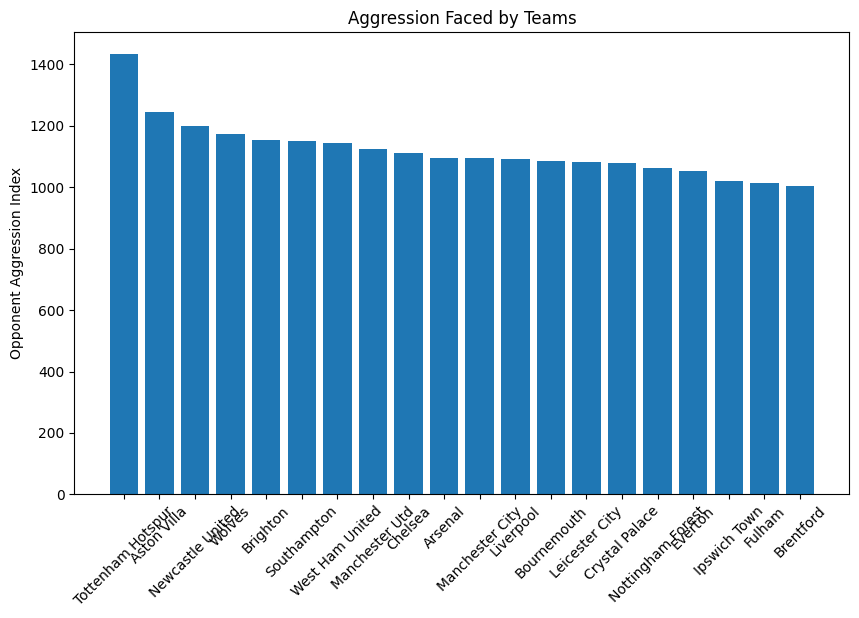

In [9]:
plt.figure(figsize=(10,6))

plt.bar(
    pressure_rank["team"],
    pressure_rank["opponent_aggression_index"]
)

plt.xticks(rotation=45)
plt.ylabel("Opponent Aggression Index")
plt.title("Aggression Faced by Teams")

plt.show()